# Lab Assignment 14: Testing Hypotheses

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**

- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods used!

**Recommended Readings**:

* [Sampling Methods Guide](https://drive.google.com/file/d/1UtNdxDdI5XphWvwgTjODiAUFwArpZtoK/view)
* [Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

## 1. Vaccinations Across The Nation

A vaccination clinic has two types of vaccines against a disease. Each person who comes in to be vaccinated gets either Vaccine 1 or Vaccine 2. One week, everyone who came in on Monday, Wednesday, and Friday was given Vaccine 1. Everyone who came in on Tuesday and Thursday was given Vaccine 2. The clinic is closed on weekends.

Doctor DeNero at the clinic said, "Oh wow, the distribution of vaccines is like tossing a coin that lands heads with probability $\frac{3}{5}$. If the coin lands on heads, you get Vaccine 1 and if the coin lands on tails, you get Vaccine 2."

But Doctor Sahai said, "No, it's not. We're not doing anything like tossing a (biased) coin."

That week, the clinic gave Vaccine 1 to 211 people and Vaccine 2 to 107 people. Conduct a test of hypotheses to see which doctor's position is better supported by the data.

**Question 1.1.** Given the information above, what was the sample size for the data, and what was the percentage of people who got **Vaccine 1?** **(4 points)**

*Note*: Your percent should be a number between 0 and 100, not a proportion between 0 and 1.


In [ ]:
sample_size = 211 + 107
percent_V1 = (211 / sample_size) * 100

print(f"Sample Size: {sample_size}")
print(f"Vaccine 1 Percent: {percent_V1}")

<!-- BEGIN QUESTION -->

**Question 1.2.** State the null hypothesis. It should reflect the position of either Dr. DeNero or Dr. Sahai. **(4 points)**

*Note:* Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.


In hypothesis testing, the null hypothesis must be a clearly defined probabilistic model of how the data were generated, something we can simulate.

Null hypothesis: Dr. DeNero's model is correct. That is, the data were generated through a random process (biased coin toss) where each person received vaccine 1 with a 3/5 chance and vaccine 2 with a 2/5 chance.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 1.3.** State the alternative hypothesis. It should reflect the position of the doctor you did not choose to represent in Question 1.2. **(4 points)**

*Note:* Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.


Alternative Hypothesis: Dr. Sahai's position is correct. That is, the data were not generated through the random process (biased coin toss) where each person received vaccine 1 with a 3/5 chance and vaccine 2 with a 2/5 chance. The probability of receiving Vaccine 1 is some value other than 3/5.

<!-- END QUESTION -->

**Question 1.4.** One of the test statistics below is appropriate for testing these hypotheses. Assign the variable `valid_test_stat` to the number corresponding to the correct test statistic. **(4 points)**

_Hint:_ Recall that large values of the test statistic should favor the alternative hypothesis.

1. percent of heads - 60
2. |percent of heads - 60|
3. percent of heads - 50
4. |percent of heads - 50|


In [5]:
valid_test_stat = 2
valid_test_stat

2

**Question 1.5.** Using your answer from Questions 1.1 and 1.4, find the observed value of the test statistic and assign it to the variable `observed_statistic`. Recall that the observed statistic is the test statistic value that was observed in the real life data. **(4 points)**


In [18]:
# Add the definition of percent_V1 here to ensure it's available
sample_size = 211 + 107 # sample_size is needed to calculate percent_V1
percent_V1 = (211 / sample_size) * 100

observed_statistic = abs(percent_V1 - 60)
observed_statistic

6.352201257861637

**Question 1.6.** In order to perform this hypothesis test, you must simulate the test statistic. From the four options below, pick the assumption that is needed for this simulation. Assign `assumption_needed` to an integer corresponding to the assumption. **(4 points)**

1. The statistic must be simulated under the null hypothesis.
2. The statistic must be simulated under the alternative hypothesis.
3. The statistic must be simulated under both hypotheses.
4. No assumptions are needed. We can just simulate the statistic.


In [14]:
assumption_needed = 1
assumption_needed

1

<!-- BEGIN QUESTION -->

**Question 1.7.** Simulate 20,000 values of the test statistic under the assumption you picked in Question 1.6. **(4 points)**

As usual, start by defining a function that simulates one value of the statistic. Your function should use `sample_proportions`. (You may find a variable defined in Question 1.1 useful here!) Then, write a `for` loop to simulate multiple values and collect them in the array `simulated_statistics`.

Use as many lines of code as you need. We have included the code that visualizes the distribution of the simulated values. The red dot represents the observed statistic you found in Question 1.5.


In [20]:
def one_simulated_statistic():
    simulated_proportions = sample_proportions(sample_size, [0.6, 0.4])
    simulated_percent_V1 = simulated_proportions[0] * 100
    return abs(simulated_percent_V1 - 60)

In [21]:
# Run the this cell a few times to see how the simulated statistic changes
one_simulated_statistic()

1.5094339622641542

In [22]:
num_simulations = 20000

simulated_statistics = make_array()
for i in np.arange(num_simulations):
    simulated_statistics = np.append(simulated_statistics, one_simulated_statistic())

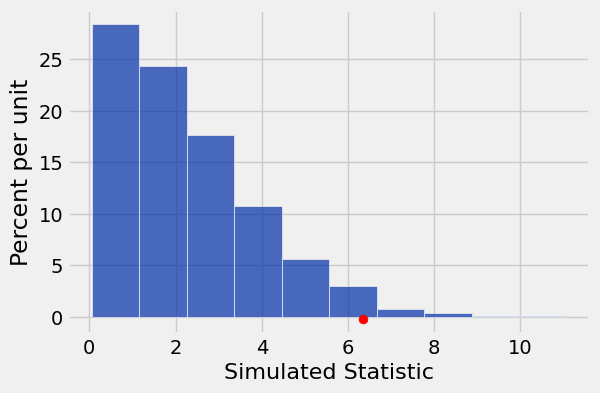

In [23]:
# Run this cell to produce a histogram of the simulated statistics

Table().with_columns('Simulated Statistic', simulated_statistics).hist()
plt.scatter(observed_statistic, -0.002, color='red', s=40);

## 2. Using TVD as a Test Statistic

Before beginning this section, read [this section](https://inferentialthinking.com/chapters/11/2/Multiple_Categories.html#a-new-statistic-the-distance-between-two-distributions) of the textbook on TVD if you want.

**Total variation distance (TVD)** is a special type of test statistic that we use when we want to compare two distributions of *categorical data*. It is often used when we observe that a set of observed proportions/probabilities is different than what we expect under the null model.

Consider a six-sided die that we roll 6,000 times. If the die is fair, we would expect that each face comes up $\frac{1}{6}$ of the time. By random chance, a fair die won't always result in equal proportions (that is, we won't get exactly 1,000 of each face). However, if we suspect that the die might be unfair based on the data, we can conduct a hypothesis test using TVD to compare the expected [$\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$] distribution to what is actually observed.

In this part of the homework, we'll look at how we can use TVD to determine the effect that different factors have on happiness.

We will be working with data from the [Gallup World Poll](https://worldhappiness.report/ed/2023/world-happiness-trust-and-social-connections-in-times-of-crisis/#ranking-of-happiness-2020-2022) that is presented in the World Happiness Report, a survey of the state of global happiness. The survey ranked 137 countries by overall happiness and estimated the influence that economic production, social support, life expectancy, freedom, absence of corruption, and generosity had on population happiness. The study has been repeated for several years, but we'll be looking at data from the 2023 survey.

Run the cell below to load in the `happiness_scores` table.

In [24]:
happiness_scores = Table.read_table("./DS/happiness_scores.csv").drop(12, 13, 14).take(np.arange(137))
happiness_scores.show(5)

Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
Denmark,Western Europe,1,7.526,7.46,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171
Switzerland,Western Europe,2,7.509,7.428,7.59,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083
Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678
Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.1269,0.79579,0.59609,0.35776,0.37895
Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492


Participants in the study were asked to evaluate their life satisfaction from a scale of 0 (worst possible life) to 10 (best possible life). The responses for each country were averaged to create the `Happiness Score`.

The columns `Economy (Log GDP per Capita)`, `Family`, `Health (Life Expectancy)`, `Freedom`, `Generosity`, and `Trust (Government Corruption)` estimate the extent to which each factor influences happiness, both for better or for worse. The happiness score is the sum of these factors; the larger a factor is, the more it contributes to overall happiness. [In other words, if you add up all the factors (in addition to a "Difference from Dystopia" value we excluded in the dataset), you get the happiness score.]

Let's look at the different factors that affect happiness in the United States. Run the cell below to view the row in `us_happiness` that contains data for the United States.

In [25]:
us_happiness = happiness_scores.where("Country", "United States")
us_happiness

Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
United States,North America,13,7.104,7.02,7.188,1.50796,1.04782,0.779,0.48163,0.14868,0.41077


**To compare the different factors, we'll look at the proportion of the happiness score that is attributed to each variable.
You can find these proportions in the table `us_happiness_factors` after running the cell below.**

*Note:* The factors shown in `us_happiness` don't add up exactly to the happiness score, so we adjusted the proportions to  only account for the data we have access to. The proportions were found by dividing each Happiness Factor value by the sum of all Happiness Factor values in `us_happiness`.

In [26]:
us_happiness_factors = Table().read_table("./DS/us_happiness_factors.csv")
us_happiness_factors

Happiness Factor,Proportion of Happiness Score
Economy (GDP per Capita),0.344609
Family,0.239455
Health (Life Expectancy),0.178022
Freedom,0.110065
Trust (Government Corruption),0.0339773
Generosity,0.0938718


<!-- BEGIN QUESTION -->

**Question 2.1.** Suppose we want to test whether or not each factor contributes the same amount to the overall Happiness Score. Define the null hypothesis, alternative hypothesis, and test statistic in the cell below. **(4 points)**

*Note:* Please format your answer as follows:
- Null Hypothesis: ...  
- Alternative Hypothesis: ...  
- Test Statistic: ...  


- Null Hypothesis: Each of the six happiness factors contributes equally to the overall Happiness Score (each contributes 1/6 of the total).
- Alternative Hypothesis: The six happiness factors do not contribute equally to the overall Happiness Score.
- Test Statistic: Total Variation Distance (TVD) between the observed proportions of contribution and the expected proportions under the null hypothesis.

<!-- END QUESTION -->

**Question 2.2.** Write a function `calculate_tvd` that takes in the observed distribution (`obs_dist`) and expected distribution under the null hypothesis (`null_dist`) and calculates the total variation distance. Use this function to set `observed_tvd` to be equal to the observed test statistic. **(4 points)**


In [28]:
null_distribution = make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6)

def calculate_tvd(obs_dist, null_dist):
    return 0.5 * np.sum(np.abs(obs_dist - null_dist))

observed_tvd = calculate_tvd(us_happiness_factors.column("Proportion of Happiness Score"), null_distribution)
observed_tvd

0.26208562431156396

**Question 2.3.** Create an array called `simulated_tvds` that contains 10,000 simulated values under the null hypothesis. Assume that the original sample consisted of 1,000 individuals. **(4 points)**

*Hint:* The `sample_proportions` function may be helpful to you. Refer to the [Python Reference Sheet](http://data8.org/fa22/reference/) to read up on it!


In [31]:
simulated_sample_size = 1000

null_distribution = make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6)

simulated_tvds = make_array()
num_simulations_tvd = 10000

for i in np.arange(num_simulations_tvd):
    simulated_proportions = sample_proportions(simulated_sample_size, null_distribution)
    simulated_tvd = calculate_tvd(simulated_proportions, null_distribution)
    simulated_tvds = np.append(simulated_tvds, simulated_tvd)

Run the cell below to plot a histogram of your simulated test statistics, as well as a red dot representing the observed value of the test statistic.

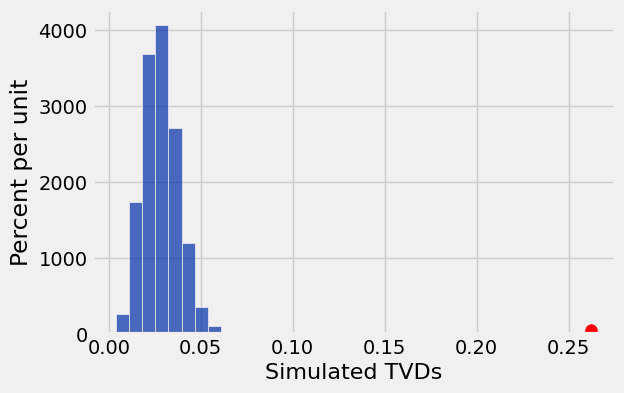

In [32]:
Table().with_column("Simulated TVDs", simulated_tvds).hist()
plt.scatter(observed_tvd, 0.5, color='red', s=70, zorder=2);
plt.show();

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [33]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab14(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab14(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab14(SSU)_files/
[NbConvertApp] Making directory ./lab14(SSU)_files
[NbConvertApp] Writing 77955 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 118494 bytes to DS/lab14(SSU).pdf
